[INFO] Total patches prepared: 2240
[INFO] Total patches prepared: 570
Epoch 1/15 | F1: 0.9076 | Acc: 0.8982
✅ Best model saved!
Epoch 2/15 | F1: 0.9250 | Acc: 0.9246
✅ Best model saved!
Epoch 3/15 | F1: 0.9241 | Acc: 0.9211
Epoch 4/15 | F1: 0.9231 | Acc: 0.9211
Epoch 5/15 | F1: 0.9284 | Acc: 0.9281
✅ Best model saved!
Epoch 6/15 | F1: 0.9084 | Acc: 0.9105
Epoch 7/15 | F1: 0.9345 | Acc: 0.9333
✅ Best model saved!
Epoch 8/15 | F1: 0.9420 | Acc: 0.9421
✅ Best model saved!
Epoch 9/15 | F1: 0.9025 | Acc: 0.9053
Epoch 10/15 | F1: 0.9269 | Acc: 0.9281
Epoch 11/15 | F1: 0.9104 | Acc: 0.9140
Epoch 12/15 | F1: 0.9310 | Acc: 0.9316
Epoch 13/15 | F1: 0.9326 | Acc: 0.9333
Epoch 14/15 | F1: 0.9307 | Acc: 0.9316
Epoch 15/15 | F1: 0.9307 | Acc: 0.9316
=== Classification Report ===
              precision    recall  f1-score   support

     Healthy       0.92      0.94      0.93       285
       Tumor       0.94      0.92      0.93       285

    accuracy                           0.93       570
   ma

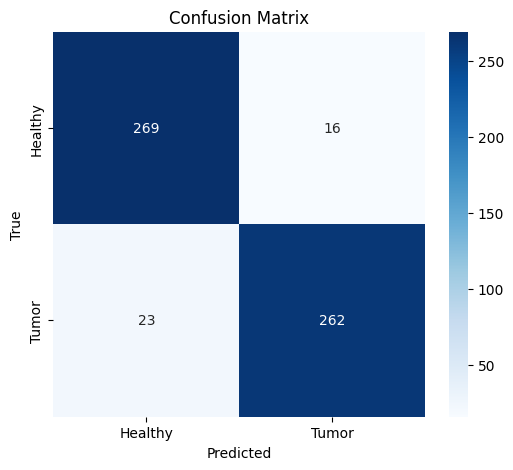

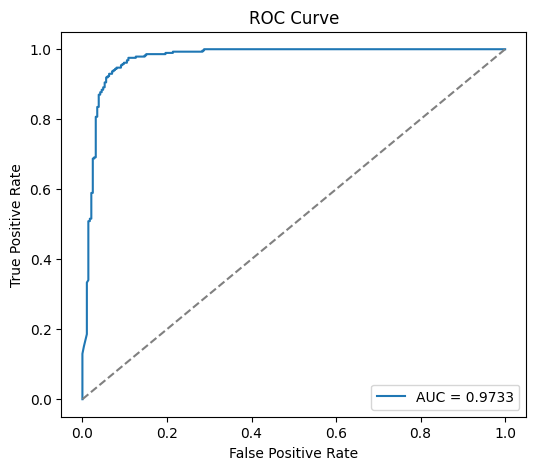

✅ Model saved as best_3d_swin_final.pth


In [2]:
# ================= INSTALL =================
!pip install monai timm -q

# ================= IMPORTS =================
import os
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
import warnings
warnings.filterwarnings("ignore")

# MONAI Swin backbone
from monai.networks.nets.swin_unetr import SwinTransformer as MonaiSwinTransformer

# ================= CONFIG =================
PATCH_SIZE = 64
BATCH_SIZE = 4
EPOCHS = 15
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BASE_PATH = "/kaggle/input/datasets/rksran k1/pancreatic-cancer/Task07_Pancreas"
IMAGE_DIR = os.path.join(BASE_PATH, "imagesTr")
MASK_DIR = os.path.join(BASE_PATH, "labelsTr")

# ================= DATASET =================
class Pancreas3DPatchDataset(Dataset):
    def __init__(self, files, patch_size=PATCH_SIZE):
        self.files = files
        self.patch_size = patch_size
        self.samples = self._prepare_samples()
        if len(self.samples) == 0:
            raise ValueError(f"No valid patches found in {len(files)} files!")

    def _prepare_samples(self):
        samples = []
        for file in self.files:
            if file.startswith("._"): 
                continue
            mask_path = os.path.join(MASK_DIR, file)
            if not os.path.exists(mask_path): 
                continue

            mask_vol = nib.load(mask_path).get_fdata()
            tumor_indices = np.argwhere(mask_vol == 2)
            if len(tumor_indices) > 0:
                # 5 Tumor samples per patient
                for _ in range(5):
                    rand_idx = np.random.randint(len(tumor_indices))
                    samples.append((file, tumor_indices[rand_idx], 1))
                # 5 Healthy samples per patient
                h, w, d = mask_vol.shape
                healthy_count = 0
                while healthy_count < 5:
                    rp = [np.random.randint(0,h), np.random.randint(0,w), np.random.randint(0,d)]
                    if mask_vol[tuple(rp)] == 0:
                        samples.append((file, rp, 0))
                        healthy_count += 1
        print(f"[INFO] Total patches prepared: {len(samples)}")
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file, center, label = self.samples[idx]
        img_vol = nib.load(os.path.join(IMAGE_DIR, file)).get_fdata()
        z, y, x = [int(c) for c in center]

        # Extract 3D Patch
        z_s, y_s, x_s = max(0, z-PATCH_SIZE//2), max(0, y-PATCH_SIZE//2), max(0, x-PATCH_SIZE//2)
        patch = img_vol[z_s:z_s+PATCH_SIZE, y_s:y_s+PATCH_SIZE, x_s:x_s+PATCH_SIZE]

        # Padding
        if patch.shape != (PATCH_SIZE, PATCH_SIZE, PATCH_SIZE):
            patch = np.pad(patch, [(0, PATCH_SIZE - patch.shape[0]),
                                   (0, PATCH_SIZE - patch.shape[1]),
                                   (0, PATCH_SIZE - patch.shape[2])], mode='constant')

        # Normalize intensity
        patch = np.clip(patch, -100, 200)
        patch = (patch + 100) / 300.0

        return torch.tensor(patch[np.newaxis,...], dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# ================= DATA LOADERS =================
all_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith((".nii", ".nii.gz")) and not f.startswith(".")])
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

train_loader = DataLoader(Pancreas3DPatchDataset(train_files), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(Pancreas3DPatchDataset(val_files), batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

# ================= MODEL =================
class Swin3DClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = MonaiSwinTransformer(
            in_chans=1,
            embed_dim=48,
            window_size=(7,7,7),
            patch_size=(4,4,4),
            depths=(2,2,6,2),
            num_heads=(3,6,12,24),
            spatial_dims=3,
        )
        self.global_avg_pool = nn.AdaptiveAvgPool3d(1)
        self.classifier = nn.Linear(768, 2)

    def forward(self, x):
        features = self.backbone(x)[-1]
        x = self.global_avg_pool(features)
        x = torch.flatten(x, 1)
        return self.classifier(x)

model = Swin3DClassifier().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ================= TRAINING =================
best_f1 = 0
for epoch in range(EPOCHS):
    model.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
    scheduler.step()

    # Validation
    model.eval()
    preds, gts, probs = [], [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            probs.extend(F.softmax(out, dim=1)[:,1].cpu().numpy())
            preds.extend(out.argmax(1).cpu().numpy())
            gts.extend(labels.cpu().numpy())

    f1 = f1_score(gts, preds)
    acc = accuracy_score(gts, preds)
    print(f"Epoch {epoch+1}/{EPOCHS} | F1: {f1:.4f} | Acc: {acc:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_3d_swin.pth")
        print("✅ Best model saved!")

# ================= CLASSIFICATION REPORT =================
print("=== Classification Report ===")
print(classification_report(gts, preds, target_names=["Healthy","Tumor"]))

# ================= CONFUSION MATRIX =================
cm = confusion_matrix(gts, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Healthy","Tumor"], yticklabels=["Healthy","Tumor"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ================= ROC & AUC =================
fpr, tpr, thresholds = roc_curve(gts, probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ================= SAVE MODEL =================
torch.save(model.state_dict(), "best_3d_swin_final.pth")
print("✅ Model saved as best_3d_swin_final.pth")